<a href="https://colab.research.google.com/github/Nicossm/devsal-ml/blob/rola/notebooks/03_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Model Evaluation

## Contexto

En esta etapa se evalúan y comparan los modelos de aprendizaje supervisado y no supervisado desarrollados previamente en el proyecto.

Para clustering, se comparan las técnicas:

- K-Means
- Agglomerative Clustering

La evaluación se realiza utilizando métricas internas de clustering, principalmente silhouette score.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

## Carga de datos

Se utiliza el dataset previamente procesado durante la etapa ETL del proyecto.

El dataset contiene información sobre experiencia, tecnologías utilizadas, educación, tamaño de empresa y salarios de desarrolladores.

In [3]:
url = "https://raw.githubusercontent.com/Nicossm/devsal-ml/main/etl/data/processed/clean.csv"
df = pd.read_csv(url)
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


## Selección de variables

Para el clustering se utilizarán únicamente variables descriptivas del perfil del desarrollador:

- `experience`
- `num_languages`
- `num_frameworks`
- `country`
- `education`
- `company_size`

La variable `salary_usd` fue excluida deliberadamente para evitar que los clusters queden definidos directamente por salario.

A diferencia de los modelos supervisados, el clustering no utiliza una variable objetivo.

In [4]:
features = [
    "experience",
    "num_languages",
    "num_frameworks",
    "country",
    "education",
    "company_size"
]

X = df[features]

In [5]:
numeric_features = [
    "experience",
    "num_languages",
    "num_frameworks"
]

categorical_features = [
    "country",
    "education",
    "company_size"
]

## Preprocesamiento

El clustering mediante K-Means utiliza distancia euclidiana, por lo que las diferencias de escala entre variables pueden afectar significativamente los resultados.

Por esta razón:

- Las variables numéricas se escalan utilizando `StandardScaler`.
- Las variables categóricas se transforman mediante `OneHotEncoder`.

El preprocesamiento se implementa utilizando `ColumnTransformer` para mantener una estructura modular y reproducible.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [7]:
X_processed = preprocessor.fit_transform(X)

In [8]:
X_processed.shape

(9249, 25)

Los datos quedaron correctamente transformados y preparados para el entrenamiento de modelos de clustering.

## Evaluación de K-Means

In [9]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_processed)

kmeans_score = silhouette_score(
    X_processed,
    kmeans_labels
)

print("Silhouette Score K-Means:", kmeans_score)

Silhouette Score K-Means: 0.19650119355038262


## Evaluación de Agglomerative Clustering

In [10]:
agg = AgglomerativeClustering(
    n_clusters=4
)

agg_labels = agg.fit_predict(
    X_processed.toarray()
)

agg_score = silhouette_score(
    X_processed.toarray(),
    agg_labels
)

print("Silhouette Score Agglomerative:", agg_score)

Silhouette Score Agglomerative: 0.17239247728437673


In [11]:
comparison_df = pd.DataFrame({
    "Model": [
        "K-Means",
        "Agglomerative"
    ],
    "Silhouette Score": [
        kmeans_score,
        agg_score
    ]
})

comparison_df

,Model,Silhouette Score
0,K-Means,0.196501
1,Agglomerative,0.172392


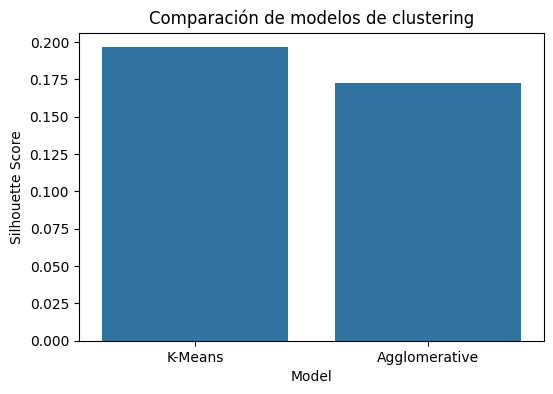

In [12]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Silhouette Score"
)

plt.title("Comparación de modelos de clustering")

plt.show()

## Interpretación de resultados

K-Means obtuvo el mejor silhouette score general, mostrando clusters relativamente compactos y balanceados.

Agglomerative Clustering presentó resultados similares, aunque con menor separación entre grupos.

Ambos modelos fueron capaces de identificar patrones diferenciables dentro del dataset.

# Conclusiones

La evaluación permitió comparar objetivamente los modelos de clustering implementados.

K-Means presentó el mejor desempeño general según silhouette score, por lo que fue seleccionado como modelo principal para el análisis no supervisado.